In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# 1. Load data
# -----------------------------
X = pd.read_csv("logisticX.csv", header=None).values
y = pd.read_csv("logisticY.csv", header=None).values.flatten()

In [4]:
# -----------------------------
# 2. Normalize features
# -----------------------------
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_norm = (X - mean) / std

In [5]:
# -----------------------------
# 3. Add intercept term
# -----------------------------
m = X.shape[0]
X_final = np.hstack([np.ones((m, 1)), X_norm])  # shape (m, 3)


In [6]:
# -----------------------------
# 4. Sigmoid function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
# -----------------------------
# 5. Newton's Method
# -----------------------------
theta = np.zeros(X_final.shape[1])  # initialize θ = 0

for i in range(10):  # iterations (usually converges fast)
    
    z = X_final @ theta
    h = sigmoid(z)
    
    # Gradient
    grad = X_final.T @ (y - h)
    
    # Hessian
    W = np.diag(h * (1 - h))
    H = - X_final.T @ W @ X_final
    
    # Update
    theta = theta - np.linalg.inv(H) @ grad

print("Final theta:", theta)


Final theta: [ 0.40125316  2.5885477  -2.72558849]


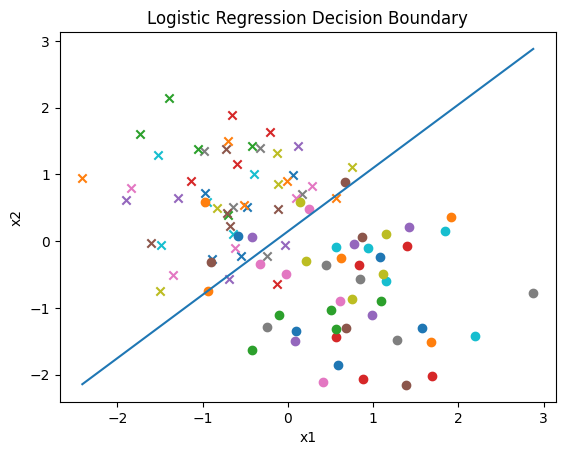

In [8]:
# -----------------------------
# 6. Plot data + decision boundary
# -----------------------------
plt.figure()

# Plot points
for i in range(m):
    if y[i] == 1:
        plt.scatter(X_norm[i, 0], X_norm[i, 1], marker='o')
    else:
        plt.scatter(X_norm[i, 0], X_norm[i, 1], marker='x')

# Decision boundary: θ0 + θ1 x1 + θ2 x2 = 0
x1_vals = np.linspace(min(X_norm[:, 0]), max(X_norm[:, 0]), 100)
x2_vals = -(theta[0] + theta[1]*x1_vals) / theta[2]

plt.plot(x1_vals, x2_vals)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")
plt.show()